# Figure 3E - Measured Regrowth complementation assay

## Overview
This notebook shows regrowth fractions of S. aureus when exposed to ΔΔrhlApqsL double mutant complemented with exogenous HQNO adn RHL. It generates publication figures (3E))


In [1]:
# Data analysis packages
import numpy as np
import pandas as pd

# Visualization packages
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

# File handling
import os


Data loaded successfully!
  WT:         20 rows
  ΔΔrhlApqsL: 20 rows

✅ Figure saved: 3E_regrowth_probability.pdf


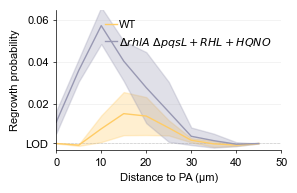

In [6]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Matplotlib style settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 8
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Strain colors
COLORS = {
    'WT': '#ffcc66',       
    'ΔrhlA ΔpqsL +RHL +HQNO': '#9999B3' 
}

# Limit of detection
LOD = 0.001

# Output file
OUTPUT_FIGURE = '3E_regrowth_probability.pdf'

# =============================================================================
# LOAD DATA
# =============================================================================


# Load regrowth fraction data from all strains (relative paths)
regrowth_wt = pd.read_csv('../../../Figure1/1E/figure_code/1_regrowth_fractions_wt_merged.csv')
regrowth_complement = pd.read_csv('3_regrowth_fractions_ext_H_R_merged.csv')

#regrowth_complement = pd.read_csv('../analysis_code/0_combined_df_complemented.csv')

print("Data loaded successfully!")
print(f"  WT:         {len(regrowth_wt)} rows")
print(f"  ΔΔrhlApqsL: {len(regrowth_complement)} rows")

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def extract_stats(df, axis='y'):
    """Extract mean, std, and bin positions for specified axis"""
    df_axis = df[df['axis'] == axis].copy().sort_values('bin_left')
    mean_vals = df_axis['mean_regrowth_fraction'].values
    std_vals = df_axis['std_regrowth_fraction'].values
    bin_positions = df_axis['bin_left'].values
    return mean_vals, std_vals, bin_positions

def plot_with_shade(ax, mean, std, y, label, color, linestyle='-'):
    """Plot mean ± std as line with shaded error region"""
    line = ax.plot(y, mean, label=label, color=color, linewidth=1, linestyle=linestyle)
    ax.fill_between(y, mean - std, mean + std, color=color, alpha=0.3)
    return line[0]

# =============================================================================
# EXTRACT Y-AXIS STATISTICS
# =============================================================================

wt_mean, wt_std, wt_y = extract_stats(regrowth_wt, axis='y')
rhlApqsL_mean, rhlApqsL_std, rhlApqsL_y = extract_stats(regrowth_complement, axis='y')

# =============================================================================
# REPLACE ZERO VALUES WITH LOD
# =============================================================================

# Replace zeros with LOD for visualization (prevents log-scale issues)
wt_mean = np.where(wt_mean == 0, LOD, wt_mean)
rhlApqsL_mean = np.where(rhlApqsL_mean == 0, LOD, rhlApqsL_mean)

# =============================================================================
# CREATE FIGURE
# =============================================================================

fig = plt.figure(figsize=(3, 2))
ax = fig.add_axes([0.20, 0.25, 0.75, 0.70])

# Plot all strains (ΔrhlA with dotted line to distinguish)
line_wt = plot_with_shade(ax, wt_mean, wt_std, wt_y, 'WT', COLORS['WT'])
line_rhlApqsL = plot_with_shade(ax, rhlApqsL_mean, rhlApqsL_std, rhlApqsL_y, 'ΔpqsL ΔrhlA +RHL +HQNO', COLORS['ΔrhlA ΔpqsL +RHL +HQNO'])

# Add LOD reference line
ax.axhline(y=LOD, color='lightgray', linestyle='--', linewidth=0.5, zorder=0)

# Axes labels and limits
ax.set_xlabel('Distance to PA (µm)', fontsize=8)
ax.set_ylabel('Regrowth probability', fontsize=8)
ax.set_xlim(0, 50)
ax.set_ylim(-0.002, 0.065)
ax.set_xticks([0, 10, 20, 30, 40, 50])

# Y-axis ticks with LOD label
y_ticks = [LOD, 0.02, 0.04, 0.06]
ax.set_yticks(y_ticks)
ax.set_yticklabels(['LOD', '0.02', '0.04', '0.06'], fontsize=8)

# Style (minimal spines, subtle grid)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(axis='both', which='major', width=0.5, length=2, labelsize=8)
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

# Legend with italic formatting for gene names
ax.legend(
    [line_wt, line_rhlApqsL], 
    ['WT', r'$\it{ΔrhlA\ ΔpqsL} +RHL +HQNO$'],
    frameon=False, fontsize=8, loc='upper right', 
    handlelength=1, handletextpad=0.2
)

# Save figure
plt.savefig(OUTPUT_FIGURE, format='pdf', bbox_inches='tight', dpi=300)
print(f"\n✅ Figure saved: {OUTPUT_FIGURE}")

plt.show()